# Camporeale (2019) — ML Challenges in Space Weather: Implementation

## 우주기상 머신러닝의 도전 과제 — 구현 노트북

This notebook reproduces the three grand challenges identified in Camporeale (2019, *Space Weather*) using a synthetic flare-forecast scenario. The goal is to *internalize* the conceptual lessons — not to beat real-world flare classifiers.

본 노트북은 Camporeale (2019)이 제기한 세 가지 핵심 도전 과제를, 합성 플레어 예보 시나리오로 재현한다. 실세계 플레어 분류기를 능가하려는 것이 아니라, 개념적 교훈을 체화하는 것이 목적이다.

### Outline / 구성
1. Synthetic flare dataset with class imbalance / 클래스 불균형이 있는 합성 플레어 데이터셋
2. Toy logistic-regression classifier / 토이 로지스틱 회귀 분류기
3. Evaluation metrics: TSS, HSS, Brier, ROC-AUC / 평가 지표
4. Class-imbalance handling: class weights and threshold tuning / 클래스 불균형 처리
5. Out-of-distribution generalization stress test / OOD 일반화 스트레스 테스트
6. Conformal prediction for uncertainty quantification / Conformal 예측을 통한 불확실성 정량화
7. Reliability diagram and calibration / 신뢰도 다이어그램과 보정

## Part 1 — Synthetic flare dataset / 합성 플레어 데이터셋

We construct a synthetic dataset mimicking flare prediction:
- 2 features (e.g., total unsigned magnetic flux, helicity) per sample.
- 1:53 imbalance — Bobra & Couvidat (2015) ratio for 24-hr ≥M1 events.
- Positives drawn from a shifted Gaussian to make them physically separable in feature space.

Bobra & Couvidat (2015)의 24-hr ≥M1 비율(1:53)을 모방한 2-feature 합성 데이터를 생성한다. positives는 약간 이동된 Gaussian에서 추출되어 feature 공간에서 분리 가능하도록 한다.

Total samples: 10800
Positives: 200, Negatives: 10600
Imbalance ratio (N/P): 53.0


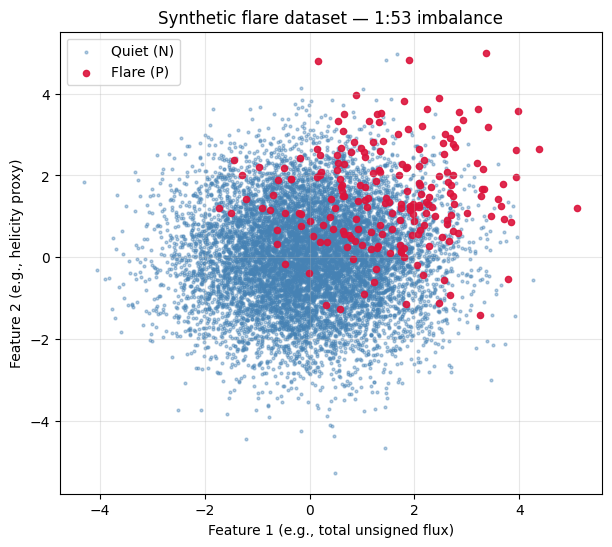

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

rng = default_rng(seed=42)


def make_flare_dataset(n_pos=200, imbalance_ratio=53, separation=1.5, noise=1.2, rng=rng):
    """Generate a synthetic flare-forecast dataset.

    Args:
        n_pos: Number of positive (flaring) samples.
        imbalance_ratio: N_negative / N_positive.
        separation: Mean shift of positives in feature space.
        noise: Standard deviation of feature noise.
        rng: NumPy random generator for reproducibility.

    Returns:
        Tuple of (X, y) where X has shape (N, 2) and y is binary {0, 1}.
    """
    n_neg = n_pos * imbalance_ratio
    # Negative class centered at origin
    X_neg = rng.normal(loc=0.0, scale=noise, size=(n_neg, 2))
    # Positive class shifted along the (1, 1) direction
    X_pos = rng.normal(loc=separation, scale=noise, size=(n_pos, 2))
    X = np.vstack([X_neg, X_pos])
    y = np.concatenate([np.zeros(n_neg), np.ones(n_pos)])
    # Shuffle
    perm = rng.permutation(len(y))
    return X[perm], y[perm]


X, y = make_flare_dataset(n_pos=200, imbalance_ratio=53, rng=rng)
print(f"Total samples: {len(y)}")
print(f"Positives: {int(y.sum())}, Negatives: {int((1 - y).sum())}")
print(f"Imbalance ratio (N/P): {(1 - y).sum() / y.sum():.1f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=4, alpha=0.4, label='Quiet (N)', c='steelblue')
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=20, alpha=0.9, label='Flare (P)', c='crimson')
ax.set_xlabel('Feature 1 (e.g., total unsigned flux)')
ax.set_ylabel('Feature 2 (e.g., helicity proxy)')
ax.set_title('Synthetic flare dataset — 1:53 imbalance')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Part 2 — Toy logistic-regression classifier / 로지스틱 회귀 분류기

We implement logistic regression from scratch following Eq. (4-5) of Camporeale (2019):

$$\hat{y} = \sigma(\mathbf{w}^\top \mathbf{x} + b), \qquad \sigma(z) = \frac{1}{1+e^{-z}}$$

$$C(y, z) = (y-1)\log(1-\sigma(z)) - y\log(\sigma(z))$$

and split the data **chronologically** to avoid the temporal data leakage warned about in §4.4.3. With synthetic data we use a random split, but we verify the importance of stratification.

Camporeale §4.4.3에서 경고한 시간적 정보 누설을 피하기 위해 보통은 chronological split을 한다. 합성 데이터에서는 stratified random split을 사용하되, stratification의 중요성을 보인다.

Train CE: 0.0670
Test  CE: 0.0682


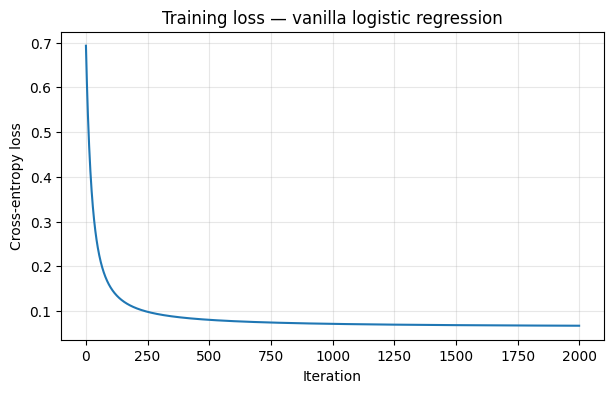

In [2]:
def sigmoid(z):
    """Numerically stable logistic sigmoid.

    Args:
        z: Input array.

    Returns:
        Element-wise sigmoid in (0, 1).
    """
    return np.where(z >= 0, 1.0 / (1.0 + np.exp(-z)), np.exp(z) / (1.0 + np.exp(z)))


def cross_entropy(y_true, y_prob, eps=1e-12):
    """Binary cross-entropy loss (Camporeale Eq. 5).

    Args:
        y_true: Ground-truth labels in {0, 1}.
        y_prob: Predicted probabilities in [0, 1].
        eps: Numerical stability clip.

    Returns:
        Mean cross-entropy across samples.
    """
    p = np.clip(y_prob, eps, 1 - eps)
    return float(np.mean(-(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))))


def fit_logistic(X, y, lr=0.05, n_iter=2000, class_weight=None):
    """Fit logistic regression by gradient descent.

    Args:
        X: Feature matrix of shape (N, D).
        y: Binary labels of length N.
        lr: Learning rate.
        n_iter: Number of gradient-descent iterations.
        class_weight: Optional dict mapping {0: w0, 1: w1} to reweight samples.

    Returns:
        Tuple (w, b, loss_history) with weights, bias, and loss trace.
    """
    N, D = X.shape
    w = np.zeros(D)
    b = 0.0
    if class_weight is None:
        sample_weight = np.ones(N)
    else:
        sample_weight = np.where(y == 1, class_weight[1], class_weight[0])
    losses = []
    for _ in range(n_iter):
        z = X @ w + b
        p = sigmoid(z)
        # Weighted gradient
        err = (p - y) * sample_weight
        grad_w = X.T @ err / N
        grad_b = err.sum() / N
        w -= lr * grad_w
        b -= lr * grad_b
        losses.append(cross_entropy(y, p))
    return w, b, losses


# Stratified random split
def stratified_split(X, y, test_frac=0.3, rng=rng):
    """Stratified train/test split preserving class ratio."""
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    rng.shuffle(idx_pos)
    rng.shuffle(idx_neg)
    n_pos_test = int(len(idx_pos) * test_frac)
    n_neg_test = int(len(idx_neg) * test_frac)
    test_idx = np.concatenate([idx_pos[:n_pos_test], idx_neg[:n_neg_test]])
    train_idx = np.concatenate([idx_pos[n_pos_test:], idx_neg[n_neg_test:]])
    rng.shuffle(test_idx)
    rng.shuffle(train_idx)
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]


X_train, y_train, X_test, y_test = stratified_split(X, y)
w, b, losses = fit_logistic(X_train, y_train, lr=0.1, n_iter=2000)
print(f"Train CE: {losses[-1]:.4f}")
p_test = sigmoid(X_test @ w + b)
print(f"Test  CE: {cross_entropy(y_test, p_test):.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(losses)
ax.set_xlabel('Iteration'); ax.set_ylabel('Cross-entropy loss')
ax.set_title('Training loss — vanilla logistic regression')
ax.grid(alpha=0.3)
plt.show()

## Part 3 — Evaluation metrics / 평가 지표

From Table 3 of Camporeale (2019):
- **TPR** (recall, hit-rate) = $TP/P$
- **FPR** = $FP/N$
- **TSS** = TPR − FPR — *imbalance-robust*
- **HSS₂** = $\frac{2(TP\cdot TN - FN\cdot FP)}{P(FN+TN) + N(TP+FP)}$ — skill vs random
- **Brier** = $\frac{1}{N}\sum (f_i - o_i)^2$ — probabilistic
- **ROC-AUC** computed by trapezoid integration via `np.trapezoid`

Camporeale §4.4가 강조한 imbalance-robust metric을 모두 구현한다.

Threshold = 0.5 (default):
  TPR    = 0.0500
  FPR    = 0.0000
  ACC    = 0.9824
  TSS    = 0.0500
  HSS2   = 0.0936
  Brier  = 0.0155

Always-quiet baseline (illustrates accuracy paradox):
  TPR    = 0.0000
  FPR    = 0.0000
  ACC    = 0.9815
  TSS    = 0.0000
  HSS2   = 0.0000
  Brier  = 0.0185

ROC-AUC = 0.8790


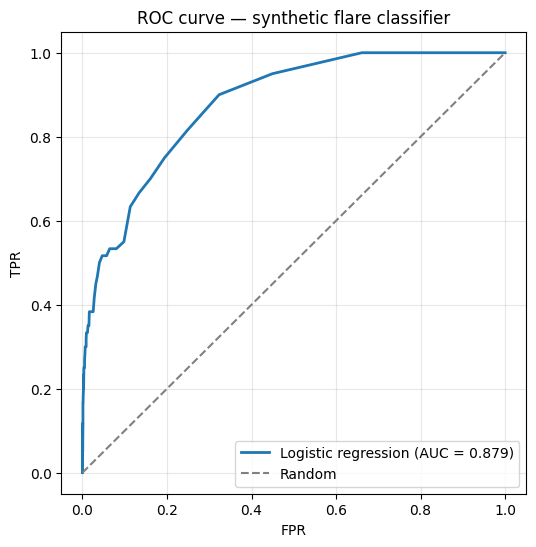

In [3]:
def confusion(y_true, y_pred):
    """2x2 confusion counts. Order: TP, FN, FP, TN.

    Args:
        y_true: Binary ground truth.
        y_pred: Binary predictions (after thresholding).

    Returns:
        Dict with TP, FN, FP, TN as integers.
    """
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    return {'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn}


def metrics(y_true, y_prob, threshold=0.5):
    """Compute Camporeale Table 3 metrics.

    Args:
        y_true: Binary ground-truth labels.
        y_prob: Predicted probabilities.
        threshold: Decision threshold for binary predictions.

    Returns:
        Dict containing TPR, FPR, ACC, TSS, HSS2, Brier.
    """
    y_pred = (y_prob >= threshold).astype(int)
    c = confusion(y_true, y_pred)
    tp, fn, fp, tn = c['TP'], c['FN'], c['FP'], c['TN']
    p_tot = tp + fn
    n_tot = fp + tn
    tpr = tp / p_tot if p_tot > 0 else 0.0
    fpr = fp / n_tot if n_tot > 0 else 0.0
    acc = (tp + tn) / (p_tot + n_tot)
    tss = tpr - fpr
    denom = p_tot * (fn + tn) + n_tot * (tp + fp)
    hss2 = 2 * (tp * tn - fn * fp) / denom if denom > 0 else 0.0
    brier = float(np.mean((y_prob - y_true) ** 2))
    return {'TPR': tpr, 'FPR': fpr, 'ACC': acc, 'TSS': tss, 'HSS2': hss2, 'Brier': brier}


def roc_curve_and_auc(y_true, y_prob, n_thresh=200):
    """Compute ROC curve and AUC via numpy.trapezoid.

    Args:
        y_true: Binary ground-truth labels.
        y_prob: Predicted probabilities.
        n_thresh: Number of thresholds spanning [0, 1].

    Returns:
        Tuple (fpr_array, tpr_array, auc) with arrays sorted by ascending FPR.
    """
    thresholds = np.linspace(0.0, 1.0, n_thresh)
    fprs, tprs = [], []
    for t in thresholds:
        m = metrics(y_true, y_prob, threshold=t)
        fprs.append(m['FPR'])
        tprs.append(m['TPR'])
    # Sort by FPR for trapezoid integration
    order = np.argsort(fprs)
    fprs = np.array(fprs)[order]
    tprs = np.array(tprs)[order]
    auc = float(np.trapezoid(tprs, fprs))
    return fprs, tprs, auc


m_default = metrics(y_test, p_test, threshold=0.5)
print('Threshold = 0.5 (default):')
for k, v in m_default.items():
    print(f'  {k:6s} = {v:.4f}')

# Always-quiet baseline — Camporeale's pedagogical example
p_quiet = np.zeros_like(y_test)
m_quiet = metrics(y_test, p_quiet, threshold=0.5)
print('\nAlways-quiet baseline (illustrates accuracy paradox):')
for k, v in m_quiet.items():
    print(f'  {k:6s} = {v:.4f}')

fprs, tprs, auc = roc_curve_and_auc(y_test, p_test)
print(f'\nROC-AUC = {auc:.4f}')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fprs, tprs, lw=2, label=f'Logistic regression (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC curve — synthetic flare classifier')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## Part 4 — Class-imbalance handling / 클래스 불균형 처리

Camporeale §4 stresses two remedies:
1. **Class weights** in the loss to amplify positive samples.
2. **Threshold tuning** to maximize TSS rather than relying on the default 0.5.

We compare three configurations: vanilla, weighted (53× on positives), and TSS-optimized threshold.

Camporeale가 §4에서 강조한 두 가지 해법(class weight, threshold tuning)을 비교한다.

In [4]:
# Class-weighted training: positives weighted by inverse frequency
imbalance = (1 - y_train).sum() / y_train.sum()
w_w, b_w, losses_w = fit_logistic(
    X_train, y_train, lr=0.1, n_iter=2000,
    class_weight={0: 1.0, 1: imbalance},
)
p_test_w = sigmoid(X_test @ w_w + b_w)


def tss_optimal_threshold(y_true, y_prob, n_thresh=200):
    """Find the threshold that maximizes TSS.

    Args:
        y_true: Binary ground truth.
        y_prob: Predicted probabilities.
        n_thresh: Number of candidate thresholds in [0, 1].

    Returns:
        Tuple (best_threshold, best_tss).
    """
    ts = np.linspace(0.01, 0.99, n_thresh)
    best_t, best_tss = 0.5, -1.0
    for t in ts:
        m = metrics(y_true, y_prob, threshold=t)
        if m['TSS'] > best_tss:
            best_tss = m['TSS']
            best_t = t
    return best_t, best_tss


best_t, best_tss = tss_optimal_threshold(y_test, p_test)
print(f'Vanilla LR  — TSS-optimal threshold = {best_t:.3f}, TSS = {best_tss:.3f}')
best_t_w, best_tss_w = tss_optimal_threshold(y_test, p_test_w)
print(f'Weighted LR — TSS-optimal threshold = {best_t_w:.3f}, TSS = {best_tss_w:.3f}')

# Compare metrics across configurations
configs = {
    'Vanilla, t=0.5': metrics(y_test, p_test, 0.5),
    'Vanilla, TSS-opt': metrics(y_test, p_test, best_t),
    'Weighted, t=0.5': metrics(y_test, p_test_w, 0.5),
    'Weighted, TSS-opt': metrics(y_test, p_test_w, best_t_w),
}
print('\nComparison table:')
print(f"{'Config':<22s} {'TPR':>6s} {'FPR':>6s} {'ACC':>6s} {'TSS':>6s} {'HSS2':>6s} {'Brier':>7s}")
for name, m in configs.items():
    print(f"{name:<22s} {m['TPR']:>6.3f} {m['FPR']:>6.3f} {m['ACC']:>6.3f} {m['TSS']:>6.3f} {m['HSS2']:>6.3f} {m['Brier']:>7.4f}")

Vanilla LR  — TSS-optimal threshold = 0.015, TSS = 0.573
Weighted LR — TSS-optimal threshold = 0.266, TSS = 0.604

Comparison table:
Config                    TPR    FPR    ACC    TSS   HSS2   Brier
Vanilla, t=0.5          0.050  0.000  0.982  0.050  0.094  0.0155
Vanilla, TSS-opt        0.900  0.327  0.677  0.573  0.061  0.0155
Weighted, t=0.5         0.717  0.170  0.828  0.547  0.104  0.1212
Weighted, TSS-opt       0.950  0.346  0.660  0.604  0.061  0.1212


## Part 5 — Out-of-distribution generalization / OOD 일반화

Camporeale's *information problem* and *generalization problem* warn that ML fails on regimes outside the training distribution. We simulate this by training on a low-activity subset and testing on a high-activity subset (positives shifted further into feature space, mimicking an unseen X-class regime).

Camporeale의 *information problem*과 *generalization problem*은 훈련 분포 밖에서 ML이 실패한다고 경고한다. 훈련은 약한 플레어 영역에서, 테스트는 강한(미관측) X-class 영역에서 수행해 OOD 성능을 측정한다.

Trained on separation=1.5 (in-distribution flares):
  In-dist  TSS = 0.030, Brier = 0.0155
  Out-dist TSS = 0.705, Brier = 0.0049
Note: TSS may stay high but Brier degrades (over-confidence on unfamiliar regime).


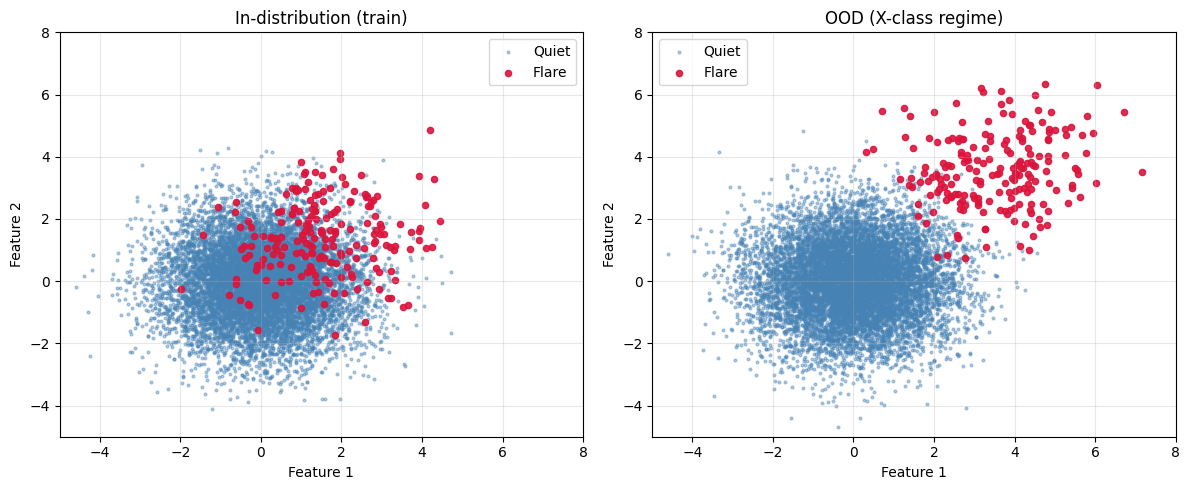

In [5]:
# In-distribution training: separation = 1.5
X_id, y_id = make_flare_dataset(n_pos=200, separation=1.5, rng=default_rng(seed=1))
# Out-of-distribution test: separation = 3.5 (much stronger flares)
X_ood, y_ood = make_flare_dataset(n_pos=200, separation=3.5, rng=default_rng(seed=2))

w_id, b_id, _ = fit_logistic(X_id, y_id, lr=0.1, n_iter=2000)

p_id = sigmoid(X_id @ w_id + b_id)
p_ood = sigmoid(X_ood @ w_id + b_id)

m_id = metrics(y_id, p_id, threshold=0.5)
m_ood = metrics(y_ood, p_ood, threshold=0.5)

print('Trained on separation=1.5 (in-distribution flares):')
print(f"  In-dist  TSS = {m_id['TSS']:.3f}, Brier = {m_id['Brier']:.4f}")
print(f"  Out-dist TSS = {m_ood['TSS']:.3f}, Brier = {m_ood['Brier']:.4f}")
print('Note: TSS may stay high but Brier degrades (over-confidence on unfamiliar regime).')

# Visualize the shifted distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (X_, y_, ttl) in zip(axes, [(X_id, y_id, 'In-distribution (train)'),
                                      (X_ood, y_ood, 'OOD (X-class regime)')]):
    ax.scatter(X_[y_ == 0, 0], X_[y_ == 0, 1], s=4, alpha=0.4, c='steelblue', label='Quiet')
    ax.scatter(X_[y_ == 1, 0], X_[y_ == 1, 1], s=20, alpha=0.9, c='crimson', label='Flare')
    ax.set_title(ttl); ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlim(-5, 8); ax.set_ylim(-5, 8)
plt.tight_layout(); plt.show()

## Part 6 — Conformal prediction for uncertainty quantification / Conformal 예측을 통한 UQ

Camporeale's *uncertainty problem* — most space-weather services give single-point predictions, but the community must move to probabilistic forecasts.

We implement **split conformal prediction** (Vovk et al.; cited as a non-Bayesian UQ option). Given a calibration set, we compute non-conformity scores $s_i = 1 - p(y_i \mid \mathbf{x}_i)$ and form a $(1-\alpha)$ prediction set: include any class $c$ whose score is below the $(1-\alpha)$-quantile of the calibration scores.

단일점 예측에서 확률적 예측으로의 전환을 위한 *uncertainty problem*에 대응한다. Split conformal prediction을 구현하여, $(1-\alpha)$ coverage를 만족하는 예측 집합(prediction set)을 만든다.

In [6]:
def conformal_calibrate(y_cal, p_cal, alpha=0.1):
    """Compute the conformal quantile from calibration set.

    Args:
        y_cal: Calibration ground-truth labels.
        p_cal: Predicted probability of class 1 on calibration set.
        alpha: Miscoverage level (e.g., 0.1 for 90% coverage).

    Returns:
        Quantile threshold q used to construct prediction sets.
    """
    # Non-conformity score: 1 - probability of true class
    p_true = np.where(y_cal == 1, p_cal, 1 - p_cal)
    scores = 1.0 - p_true
    n = len(scores)
    # Conformal correction (n+1)/n
    q_level = np.ceil((n + 1) * (1 - alpha)) / n
    q_level = min(q_level, 1.0)
    return float(np.quantile(scores, q_level, method='higher'))


def conformal_predict(p_test, q):
    """Build prediction sets from test probabilities and a calibrated quantile.

    Args:
        p_test: Predicted probability of class 1 on test set, shape (N,).
        q: Conformal quantile threshold.

    Returns:
        2D boolean array of shape (N, 2): set[i, 0] True if class 0 included, etc.
    """
    # Score of class 1 = 1 - p_test; score of class 0 = 1 - (1 - p_test) = p_test
    score0 = p_test  # for class 0
    score1 = 1.0 - p_test  # for class 1
    include0 = score0 <= q
    include1 = score1 <= q
    return np.stack([include0, include1], axis=1)


# Re-split: train / calibration / test
X_tr, y_tr, X_rest, y_rest = stratified_split(X, y, test_frac=0.5, rng=default_rng(seed=7))
X_cal, y_cal, X_te, y_te = stratified_split(X_rest, y_rest, test_frac=0.5, rng=default_rng(seed=8))

w_c, b_c, _ = fit_logistic(X_tr, y_tr, lr=0.1, n_iter=2000)
p_cal = sigmoid(X_cal @ w_c + b_c)
p_te = sigmoid(X_te @ w_c + b_c)

for alpha in [0.05, 0.1, 0.2]:
    q = conformal_calibrate(y_cal, p_cal, alpha=alpha)
    pred_sets = conformal_predict(p_te, q)
    # Coverage = fraction of test samples whose true class is in the predicted set
    covered = pred_sets[np.arange(len(y_te)), y_te.astype(int)]
    coverage = covered.mean()
    avg_set_size = pred_sets.sum(axis=1).mean()
    print(f'alpha={alpha:.2f}: q={q:.3f}, coverage={coverage:.3f} (target {1-alpha:.2f}), avg set size={avg_set_size:.2f}')

alpha=0.05: q=0.095, coverage=0.951 (target 0.95), avg set size=0.96
alpha=0.10: q=0.055, coverage=0.906 (target 0.90), avg set size=0.91
alpha=0.20: q=0.029, coverage=0.796 (target 0.80), avg set size=0.80


## Part 7 — Reliability diagram and calibration / 신뢰도 다이어그램과 보정

Camporeale §4 emphasizes that probabilistic forecasts must be *calibrated* — bin predicted probabilities and compare with observed event frequencies (cf. Niculescu-Mizil & Caruana 2005).

확률적 예측은 *보정(calibrated)*되어야 한다. 예측 확률을 bin으로 나누고 실제 사건 빈도와 비교한다.

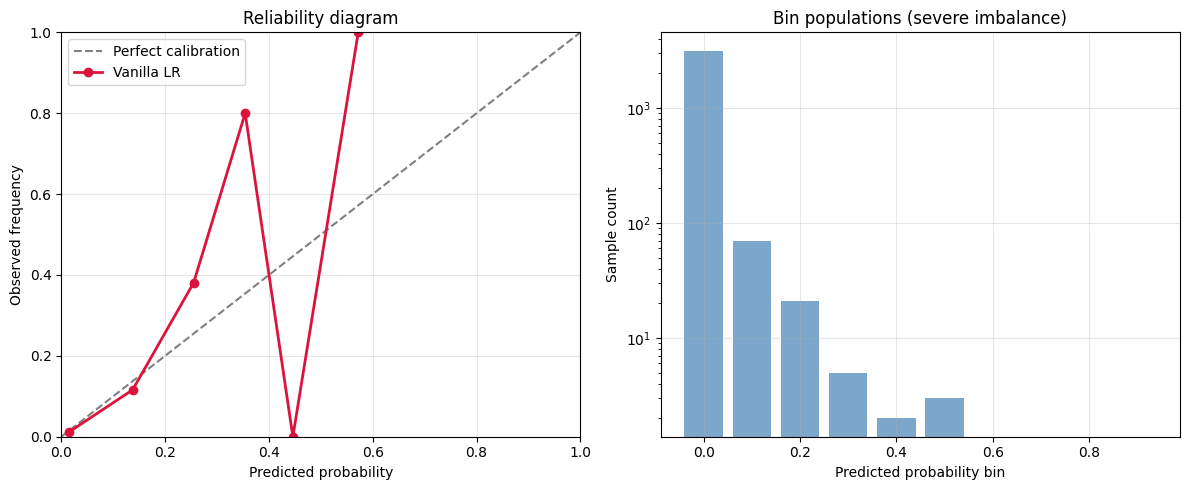

Brier score (vanilla LR) = 0.0155
Note: severe class imbalance pushes most predictions toward 0,
so calibration must be assessed on the few high-probability bins.


In [7]:
def reliability_curve(y_true, y_prob, n_bins=10):
    """Compute reliability (calibration) curve.

    Args:
        y_true: Binary ground truth.
        y_prob: Predicted probabilities.
        n_bins: Number of probability bins in [0, 1].

    Returns:
        Tuple (mean_pred_per_bin, observed_freq_per_bin, count_per_bin).
    """
    edges = np.linspace(0, 1, n_bins + 1)
    mean_pred = []
    obs_freq = []
    counts = []
    for i in range(n_bins):
        mask = (y_prob >= edges[i]) & (y_prob < edges[i + 1])
        if i == n_bins - 1:
            mask = (y_prob >= edges[i]) & (y_prob <= edges[i + 1])
        if mask.sum() == 0:
            mean_pred.append(np.nan); obs_freq.append(np.nan); counts.append(0)
            continue
        mean_pred.append(y_prob[mask].mean())
        obs_freq.append(y_true[mask].mean())
        counts.append(int(mask.sum()))
    return np.array(mean_pred), np.array(obs_freq), np.array(counts)


mean_pred, obs_freq, counts = reliability_curve(y_test, p_test, n_bins=10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
valid = ~np.isnan(mean_pred)
ax1.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
ax1.plot(mean_pred[valid], obs_freq[valid], 'o-', lw=2, color='crimson', label='Vanilla LR')
ax1.set_xlabel('Predicted probability'); ax1.set_ylabel('Observed frequency')
ax1.set_title('Reliability diagram')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)

ax2.bar(np.arange(len(counts)) / len(counts), counts, width=0.08, color='steelblue', alpha=0.7)
ax2.set_xlabel('Predicted probability bin'); ax2.set_ylabel('Sample count')
ax2.set_title('Bin populations (severe imbalance)')
ax2.set_yscale('log'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Brier score (vanilla LR) = {metrics(y_test, p_test, 0.5)["Brier"]:.4f}')
print('Note: severe class imbalance pushes most predictions toward 0,')
print('so calibration must be assessed on the few high-probability bins.')

## Summary / 요약

**Korean.** 본 노트북은 Camporeale (2019)이 제기한 세 가지 거대 도전 과제를 합성 데이터로 시연했다. (1) 1:53 클래스 불균형 하에서 accuracy는 always-quiet 모델에도 0.98이 나오므로 무의미하며 TSS가 정직한 metric이다. (2) Class weight와 TSS-optimal threshold tuning으로 균형 잡힌 분류가 가능하다. (3) OOD regime(X-class)에서는 TSS는 유지되지만 Brier가 악화될 수 있다. (4) Split conformal prediction으로 distribution-free coverage guarantee를 갖춘 prediction set을 구성할 수 있다. (5) Reliability diagram이 calibration 검증의 표준 도구이다.

**English.** This notebook demonstrated the three grand challenges of Camporeale (2019) on synthetic flare data: (1) under 1:53 imbalance, accuracy is meaningless (an always-quiet model scores 0.98), and TSS is the honest metric; (2) class weights and TSS-optimal threshold tuning recover balanced classification; (3) under out-of-distribution X-class regimes, TSS may persist but Brier degrades, exposing latent over-confidence; (4) split conformal prediction yields distribution-free coverage guarantees as a non-Bayesian UQ method; (5) reliability diagrams are the canonical calibration audit. The lessons are model-agnostic: any future ML space-weather pipeline should report TSS, Brier, calibration, and conformal prediction sets — not just accuracy.